In [ ]:
# =====================================================================
# CELDA DE COMPATIBILIDAD - Google Colab / Local
# ---------------------------------------------------------------------
# Este notebook funciona IGUAL en dos entornos:
#   * LOCAL  -> usa el venv del proyecto (Python 3.12) y el CSV de data/raw/
#   * COLAB  -> instala las dependencias y descarga el dataset al vuelo
# No hay que tocar nada: la deteccion es automatica.
# =====================================================================
import sys
import subprocess
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    print("Entorno detectado: GOOGLE COLAB -> instalando dependencias...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "pandas", "numpy", "matplotlib", "seaborn",
         "scikit-learn", "imbalanced-learn", "ucimlrepo"],
        check=True,
    )
    # En Colab no existe el repositorio clonado: se arma la estructura minima
    RAIZ = Path("/content/DefenzaGrado")
    (RAIZ / "data" / "raw").mkdir(parents=True, exist_ok=True)
    (RAIZ / "outputs" / "figuras").mkdir(parents=True, exist_ok=True)

    ruta_csv = RAIZ / "data" / "raw" / "desercion_estudiantil.csv"
    if not ruta_csv.exists():
        print("Descargando dataset UCI id=697 ...")
        import pandas as pd
        from ucimlrepo import fetch_ucirepo
        repo = fetch_ucirepo(id=697)
        pd.concat([repo.data.features, repo.data.targets], axis=1).to_csv(
            ruta_csv, index=False, encoding="utf-8"
        )
        print(f"Dataset guardado en {ruta_csv}")
    else:
        print("El dataset ya estaba descargado.")
else:
    print("Entorno detectado: LOCAL -> no se instala nada.")
    # El notebook vive en notebooks/, la raiz del proyecto esta un nivel arriba
    RAIZ = Path.cwd()
    if not (RAIZ / "data").exists():
        RAIZ = RAIZ.parent

# Rutas que usa TODO el notebook a partir de aqui
DIR_DATOS = RAIZ / "data" / "raw"
DIR_FIGURAS = RAIZ / "outputs" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
RUTA_CSV = DIR_DATOS / "desercion_estudiantil.csv"

print(f"\nRaiz del proyecto : {RAIZ}")
print(f"CSV del dataset   : {RUTA_CSV}  (existe: {RUTA_CSV.exists()})")
print(f"Figuras se guardan: {DIR_FIGURAS}")

Entorno detectado: LOCAL -> no se instala nada.

Raiz del proyecto : D:\_Dev\Projects\DefenzaGrado
CSV del dataset   : D:\_Dev\Projects\DefenzaGrado\data\raw\desercion_estudiantil.csv  (existe: True)
Figuras se guardan: D:\_Dev\Projects\DefenzaGrado\outputs\figuras


# Sistema de Alerta Temprana para la Desercion Estudiantil

**Examen de Grado - Ingenieria de Sistemas (UTEPSA)**
**Area:** Inteligencia Artificial | **Caso #01**
**Fecha de defensa:** 13 de agosto de 2026

---

**Objetivo:** construir un clasificador **Random Forest** que identifique, lo antes
posible, a los estudiantes con alto riesgo de desertar durante los primeros
semestres de carrera, para que la universidad pueda intervenir a tiempo.

**Dataset:** *Predicting Student Dropout and Academic Success* -- UCI Machine
Learning Repository, id **697**.
<https://archive.ics.uci.edu/dataset/697/predicting+student+dropout+and+academic+success>

**Metodologia:** CRISP-DM (Cross Industry Standard Process for Data Mining), sus
6 fases estructuran este notebook:

| # | Fase | Que se responde |
|---|------|-----------------|
| 1 | Comprension del Negocio | Que problema resolvemos y como se mide el exito |
| 2 | Comprension de los Datos | Que tenemos, en que estado, que dice el target |
| 3 | Preparacion de los Datos | Como dejamos los datos listos para el modelo |
| 4 | Modelado | Random Forest: entrenamiento y ajuste de hiperparametros |
| 5 | Evaluacion | Metricas, matriz de confusion, ROC, importancia de variables |
| 6 | Implementacion | Como se llevaria esto a produccion en la universidad |

> **Nota sobre este notebook:** la carga de datos (Fases 1-2) esta resuelta y
> verificada. **De la Fase 3 en adelante el codigo esta como `# TODO`**: se
> escribe a mano, porque hay que poder defender cada decision ante el tribunal.

---

## Fase 1 - Comprension del Negocio

### 1.1 El problema

La desercion estudiantil temprana (primeros 4 semestres) le cuesta a la
universidad matriculas perdidas, indicadores de calidad a la baja y capacidad
instalada ociosa; y le cuesta al estudiante tiempo, dinero y, muchas veces, la
carrera. El problema real no es *contar* desertores al final del año: es
**detectarlos mientras todavia se puede hacer algo**.

### 1.2 Objetivo de negocio

Entregar a Bienestar Estudiantil una lista priorizada de estudiantes en riesgo,
al cierre de cada semestre, para activar tutorias, apoyo economico o
acompañamiento academico.

### 1.3 Objetivo de mineria de datos

Entrenar un clasificador **binario** (`desertor` / `no desertor`) sobre las
variables socioeconomicas, academicas y de contexto disponibles al momento de la
matricula y del primer/segundo semestre.

El target original tiene 3 clases (`Dropout`, `Enrolled`, `Graduate`) y **se
simplifica a binario**. Esa simplificacion es una decision a justificar en la
defensa (ver TODO en la Fase 3).

### 1.4 Criterio de exito

En alerta temprana, **el error caro es el falso negativo**: un estudiante que va
a desertar y el sistema no marca es una intervencion que nunca ocurrio. Un falso
positivo, en cambio, solo cuesta una tutoria de mas.

Por eso la metrica que manda es el **recall de la clase `desertor`**, acompañada
de F1 y ROC-AUC para no degradar demasiado la precision. *Accuracy* sola no
sirve: con ~32% de desertores, un modelo que diga "nadie deserta" acierta 68% y
es inutil.

### 1.5 Por que Random Forest

- Maneja mezcla de variables numericas y categoricas sin exigir escalado.
- Robusto a outliers y a relaciones no lineales.
- Entrega **importancia de variables**, que es lo que hace accionable la alerta:
  no basta con decir "este estudiante esta en riesgo", hay que decir por que.
- Menos propenso al sobreajuste que un arbol unico, gracias al bagging.

## Fase 2 - Comprension de los Datos

Se carga el dataset ya descargado por `src/cargar_datos.py` y se revisa su
forma, tipos, nulos y la distribucion del target. Esta fase **si esta resuelta**:
es el punto de partida comun para todo lo que sigue.

Si el CSV no existe todavia, ejecutar antes desde la raiz del proyecto:

```bash
python src/cargar_datos.py
```

In [ ]:
# --- Librerias y configuracion global de graficos ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Todas las figuras se exportan a 300 dpi para que entren con calidad en el Word
DPI_EXPORT = 300
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = DPI_EXPORT
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid", palette="deep")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SEMILLA = 42  # reproducibilidad: mismo resultado en cada corrida

print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"matplotlib   {plt.matplotlib.__version__}")
print(f"seaborn      {sns.__version__}")

pandas       3.0.5
numpy        2.5.1
matplotlib   3.11.1
seaborn      0.13.2


In [ ]:
# --- Carga del dataset ---
if not RUTA_CSV.exists():
    raise FileNotFoundError(
        f"No se encontro {RUTA_CSV}.\n"
        "Ejecuta primero desde la raiz del proyecto:  python src/cargar_datos.py"
    )

df = pd.read_csv(RUTA_CSV)

print(f"Forma del dataset (filas, columnas): {df.shape}")
print(f"Filas    : {df.shape[0]:,}")
print(f"Columnas : {df.shape[1]}")

Forma del dataset (filas, columnas): (4424, 37)
Filas    : 4,424
Columnas : 37


In [ ]:
# --- Primeras filas ---
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# --- Tipos de dato, memoria y valores nulos ---
df.info()

print("\n--- Nulos por columna (solo las que tienen) ---")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
if nulos.empty:
    print("No hay valores nulos declarados en el dataset.")
else:
    print(nulos)

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [ ]:
# --- Estadisticos descriptivos de las variables numericas ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [ ]:
# --- Distribucion del target (3 clases originales) ---
conteo = df["Target"].value_counts()
porcentaje = df["Target"].value_counts(normalize=True) * 100

resumen_target = pd.DataFrame({"cantidad": conteo, "porcentaje": porcentaje.round(2)})
print(resumen_target)

print("\nLectura rapida:")
print(f"  - Total de estudiantes  : {len(df):,}")
print(f"  - Desertores (Dropout)  : {conteo.get('Dropout', 0):,}"
      f" ({porcentaje.get('Dropout', 0):.1f}%)")
print("  - La clase 'Enrolled' (aun cursando) es el caso ambiguo:")
print("    hay que decidir en la Fase 3 si se agrupa o se descarta.")

          cantidad  porcentaje
Target                        
Graduate      2209       49.93
Dropout       1421       32.12
Enrolled       794       17.95

Lectura rapida:
  - Total de estudiantes  : 4,424
  - Desertores (Dropout)  : 1,421 (32.1%)
  - La clase 'Enrolled' (aun cursando) es el caso ambiguo:
    hay que decidir en la Fase 3 si se agrupa o se descarta.


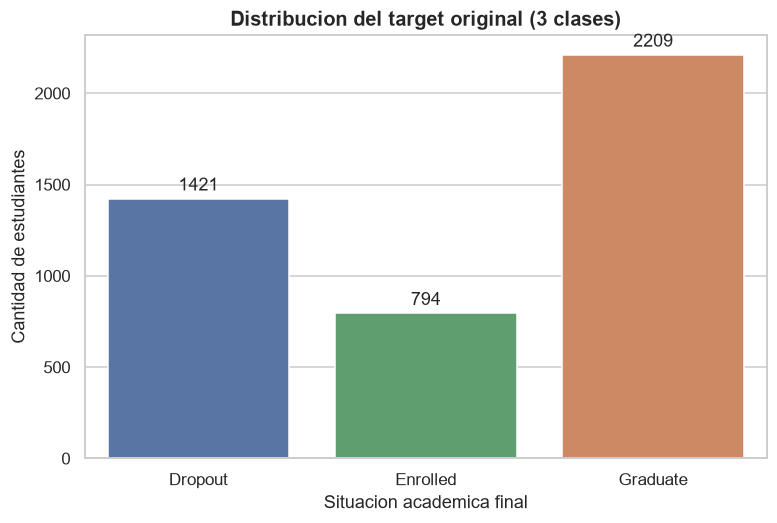

Figura guardada en: D:\_Dev\Projects\DefenzaGrado\outputs\figuras\01_distribucion_target.png


In [ ]:
# --- Figura 1: distribucion del target ---
fig, ax = plt.subplots(figsize=(8, 5))

orden = ["Dropout", "Enrolled", "Graduate"]
sns.countplot(data=df, x="Target", order=orden, hue="Target",
              legend=False, ax=ax)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d", padding=3)

ax.set_title("Distribucion del target original (3 clases)", fontsize=13, weight="bold")
ax.set_xlabel("Situacion academica final")
ax.set_ylabel("Cantidad de estudiantes")

plt.savefig(DIR_FIGURAS / "01_distribucion_target.png", dpi=DPI_EXPORT)
plt.show()

print(f"Figura guardada en: {DIR_FIGURAS / '01_distribucion_target.png'}")

### 2.1 Exploracion mas profunda (a completar)

Lo anterior es el reconocimiento minimo. El analisis exploratorio que sostiene
las decisiones de la Fase 3 todavia hay que hacerlo.

> Guia paso a paso de que se espera en cada TODO de abajo y por que le importa
> a la defensa (sin codigo resuelto): ver `08-Defensa-Grado/Guia-Fase2-EDA.md`
> en el vault.

In [ ]:
# TODO: separar las columnas en dos listas segun su naturaleza real, no segun el dtype.
#       Ojo: varias categoricas vienen codificadas como enteros (por ejemplo
#       'Marital Status', 'Application mode', 'Course', "Mother's qualification").
#       Tratarlas como numericas seria un error conceptual - hay que justificarlo.
#       Sugerencia: crear COLUMNAS_CATEGORICAS y COLUMNAS_NUMERICAS a mano,
#       apoyandose en la ficha oficial del dataset en UCI.

# TODO: revisar la cardinalidad de cada categorica (df[col].nunique()) porque de
#       eso depende si el one-hot encoding de la Fase 3 es viable o explota en columnas.

# TODO: graficar la distribucion de las variables numericas clave
#       ('Age at enrollment', 'Admission grade', 'Curricular units 1st sem (approved)',
#        'Curricular units 2nd sem (approved)', 'Curricular units 1st/2nd sem (grade)')
#       con histogramas o boxplots, y detectar outliers y asimetrias.
#       Guardar la figura como outputs/figuras/02_distribucion_numericas.png a 300 dpi.

# TODO: comparar esas mismas variables ENTRE desertores y no desertores
#       (boxplot con hue=Target). Aqui es donde aparece la senal del modelo:
#       hay que poder contar en la defensa que diferencia a un desertor.

# TODO: matriz de correlacion de las numericas (heatmap) para detectar
#       variables redundantes -- por ejemplo, 'enrolled' vs 'approved' de cada
#       semestre suelen estar muy correlacionadas.
#       Guardar como outputs/figuras/03_matriz_correlacion.png a 300 dpi.

# TODO: revisar si hay filas duplicadas (df.duplicated().sum()) y decidir que hacer.

# TODO: verificar valores imposibles o centinela: notas en 0 que en realidad
#       significan "sin evaluacion", edades fuera de rango, etc.

In [ ]:
# 1. Definicion de columnas segun su naturaleza real
COLUMNAS_CATEGORICAS = [
    'Marital Status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]

COLUMNAS_BINARIAS = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International'
]

COLUMNAS_NUMERICAS = [
    'Application order', 'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment', 'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
    'Inflation rate', 'GDP'
]

print(f"Categoricas : {len(COLUMNAS_CATEGORICAS)}")
print(f"Binarias    : {len(COLUMNAS_BINARIAS)}")
print(f"Numericas   : {len(COLUMNAS_NUMERICAS)}")
print(f"Total       : {len(COLUMNAS_CATEGORICAS) + len(COLUMNAS_BINARIAS) + len(COLUMNAS_NUMERICAS)} (de 36 features + 1 target)")

## Fase 3 - Preparacion de los Datos

Aqui se transforma el dataset crudo en la matriz `X` y el vector `y` que consume
el modelo. Cada decision de esta fase es defendible o no: no hay una respuesta
"correcta" universal, hay una respuesta **justificada** para este caso.

> A partir de aqui, todo el codigo esta como `# TODO`.

In [ ]:
# ============ 3.1 Definicion del target binario ============

# DECISION YA TOMADA (validada con los datos reales, ver 08-Defensa-Grado/
# Caso-IA-Desercion-Estudiantil.md): la clase 'Enrolled' (794 estudiantes) NO
# tiene desenlace confirmado todavia -- no se puede usar para entrenar ni para
# evaluar el modelo, porque no hay forma de saber si el numero real de aciertos
# es correcto. Se excluye del entrenamiento y se guarda aparte para usarla en la
# Fase 6 como poblacion de inferencia en vivo (la demo real: puntuar estudiantes
# actualmente matriculados, que es el caso de uso real del sistema).

# TODO: separar el dataframe en dos:
#         df_entrenamiento -> solo filas con Target en {'Dropout', 'Graduate'}
#         df_enrolled       -> solo filas con Target == 'Enrolled' (para la Fase 6)
#       Verificar que df_entrenamiento tenga 3.630 filas (1.421 Dropout + 2.209
#       Graduate) y df_enrolled tenga 794.

# TODO: sobre df_entrenamiento, crear la columna 'desertor' con 1 = Dropout,
#       0 = Graduate. Verificar el balance con value_counts() -- deberia dar
#       un ratio cercano a 1,55:1 (Graduate:Dropout), menos desbalanceado que
#       si se hubiera incluido Enrolled como clase negativa.

# TODO: separar X (variables predictoras) e y (target binario) A PARTIR DE
#       df_entrenamiento unicamente, eliminando de X la columna 'Target' original
#       para no filtrar la respuesta (data leakage: el error mas caro y el mas
#       facil de cometer). df_enrolled se deja intacto, sin columna 'desertor'
#       (no la tiene), para usarlo en la Fase 6.

In [ ]:
# ============ 3.2 Valores nulos ============

# TODO: imputar nulos -- decidir media / mediana / moda segun el TIPO de variable
#       y justificar la eleccion:
#         * numericas simetricas  -> media
#         * numericas con outliers o asimetria -> mediana (mas robusta)
#         * categoricas -> moda, o una categoria explicita "Desconocido"
#       Este dataset no reporta nulos declarados: si se confirma que no hay,
#       DEJARLO ESCRITO igual (que no haya nulos tambien es un hallazgo que
#       el tribunal puede preguntar).

# TODO: si en la Fase 2 se detectaron valores centinela (ceros que significan
#       "sin dato"), decidir si se convierten a NaN antes de imputar.

# TODO: usar SimpleImputer dentro de un Pipeline en vez de imputar sobre el df
#       completo. Motivo: si se imputa con la media de TODO el dataset, la media
#       del set de prueba se filtra al entrenamiento (data leakage sutil).

In [ ]:
# ============ 3.3 Codificacion de variables categoricas ============

# TODO: elegir la estrategia de encoding y justificarla:
#         * One-Hot (pd.get_dummies / OneHotEncoder): correcto cuando NO hay orden
#           entre las categorias (ej. 'Course', 'Marital Status', 'Nacionality').
#           Costo: agrega muchas columnas si la cardinalidad es alta.
#         * Label / Ordinal encoding: solo valido cuando SI hay orden real
#           (ej. niveles de cualificacion de los padres, si se asume jerarquia).
#       Advertencia para la defensa: aplicar label encoding a una categorica sin
#       orden le inventa una relacion de magnitud al modelo (Course 5 > Course 2).
#       Random Forest lo tolera mejor que un modelo lineal, pero sigue siendo
#       una decision que hay que poder explicar.

# TODO: las binarias ya codificadas 0/1 ('Displaced', 'Debtor', 'Gender',
#       'Scholarship holder', 'International', 'Tuition fees up to date', ...)
#       no necesitan transformacion: verificarlo y dejarlo dicho.

# TODO: aplicar el encoding con ColumnTransformer para que quede dentro del
#       Pipeline y sea reproducible en produccion (Fase 6).

In [ ]:
# ============ 3.4 Escalado (opcional para Random Forest) ============

# TODO: decidir si se escala o no. Random Forest NO lo necesita (los arboles
#       parten por umbrales, la escala les da igual). Si se va a comparar contra
#       un modelo que si lo necesita (regresion logistica, SVM, KNN), entonces
#       si -- usar StandardScaler dentro del Pipeline.
#       Escribir la justificacion: saber POR QUE no se escala vale tanto como escalar.

In [ ]:
# ============ 3.5 Division entrenamiento / prueba ============

# TODO: hacer un split ESTRATIFICADO con train_test_split(
#           X, y, test_size=0.2, random_state=SEMILLA, stratify=y)
#       El stratify=y es obligatorio: con clases desbalanceadas, un split al azar
#       puede dejar proporciones distintas de desertores en train y test y
#       ensuciar toda la evaluacion.

# TODO: verificar que la proporcion de desertores en y_train y en y_test sea
#       practicamente la misma que en el dataset completo, e imprimirlo.

# TODO: dejar el conjunto de prueba INTACTO hasta la Fase 5. No se mira, no se
#       usa para ajustar nada. Todo el ajuste se hace por validacion cruzada
#       sobre el entrenamiento.

In [ ]:
# ============ 3.6 Manejo del desbalanceo de clases ============

# TODO: cuantificar el desbalanceo real (proporcion desertor / no desertor)
#       tras la decision de 3.1.

# TODO: elegir la estrategia y justificarla. Las dos del enunciado:
#         (a) class_weight='balanced' en RandomForestClassifier
#             -> no toca los datos, penaliza mas el error en la clase minoritaria.
#                Simple, sin riesgo de leakage, sin datos sinteticos.
#         (b) SMOTE (imblearn.over_sampling.SMOTE)
#             -> genera ejemplos sinteticos de la clase minoritaria interpolando
#                vecinos. Puede subir el recall, pero inventa observaciones.
#       Lo ideal para la defensa: probar AMBAS y comparar recall/F1. Asi la
#       eleccion no es una opinion, es un resultado medido.

# TODO: SI se usa SMOTE, aplicarlo SOLO sobre el conjunto de entrenamiento y
#       DENTRO de la validacion cruzada, usando imblearn.pipeline.Pipeline
#       (no el de sklearn). Hacer SMOTE antes del split es un error clasico:
#       copias sinteticas de una misma fila terminan en train y en test a la vez,
#       las metricas salen infladas y el modelo no sirve en la realidad.
#       Este punto es un blanco tipico de pregunta del tribunal.

## Fase 4 - Modelado

Random Forest es el modelo exigido por el caso. Se entrena una linea base, se
valida con `StratifiedKFold` y recien despues se ajustan los hiperparametros.

In [ ]:
# ============ 4.1 Modelo base (linea de referencia) ============

# TODO: entrenar un RandomForestClassifier con parametros por defecto
#       (random_state=SEMILLA, class_weight segun lo decidido en 3.6).
#       Este es el punto de comparacion: si el modelo ajustado no le gana a esto,
#       el ajuste no sirvio de nada.

# TODO: entrenar tambien un clasificador trivial (DummyClassifier con
#       strategy='most_frequent') para tener el piso absoluto.
#       Sirve para demostrar en la defensa por que accuracy sola enga~a.

# TODO: registrar las metricas de ambos en una tabla comparativa para el documento.

In [ ]:
# ============ 4.2 Validacion cruzada estratificada ============

# TODO: definir StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA).
#       Estratificado porque mantiene la proporcion de desertores en cada pliegue;
#       k=5 es el valor pedido por el caso (equilibrio sesgo/varianza y costo).

# TODO: evaluar el modelo base con cross_validate() sobre multiples metricas
#       ('accuracy', 'precision', 'recall', 'f1', 'roc_auc') y reportar
#       media +/- desviacion estandar de cada una.
#       La desviacion importa: un modelo que varia mucho entre pliegues es inestable.

In [ ]:
# ============ 4.3 Ajuste de hiperparametros ============

# TODO: definir el espacio de busqueda EXACTO que pide el caso:
#         n_estimators      : 100 a 500
#         max_depth         : 5 a 20  (considerar tambien None = sin limite)
#         min_samples_split : 2 a 10
#         min_samples_leaf  : 1 a 5
#       Poder explicar que controla cada uno:
#         - n_estimators: cuantos arboles vota. Mas = mas estable, mas lento.
#         - max_depth: cuanto puede crecer cada arbol. Mas profundo = mas sobreajuste.
#         - min_samples_split / min_samples_leaf: frenos al crecimiento; suben,
#           el arbol generaliza mas y memoriza menos.

# TODO: elegir GridSearchCV o RandomizedSearchCV y justificarlo.
#       Grid recorre TODAS las combinaciones (exhaustivo pero caro);
#       Randomized muestrea n_iter combinaciones (mucho mas rapido, casi igual de
#       bueno cuando el espacio es grande). Calcular cuantas combinaciones sale
#       el grid completo antes de decidir - ese numero es un buen argumento.

# TODO: usar scoring='recall' o 'f1' (NO 'accuracy'), coherente con el criterio
#       de exito de la Fase 1.4, y cv = el StratifiedKFold de 4.2.

# TODO: ejecutar la busqueda sobre el conjunto de ENTRENAMIENTO unicamente
#       e imprimir best_params_ y best_score_.

# TODO: guardar el mejor estimador en una variable (ej. modelo_final)
#       y comparar sus metricas contra la linea base de 4.1.

In [ ]:
# ============ 4.4 (Opcional) Modelo alternativo para comparar ============

# TODO: si sobra tiempo, entrenar un XGBClassifier o un GradientBoosting con el
#       mismo split y comparar. NO reemplaza al Random Forest (el caso lo exige),
#       pero tener un contraste medido suma mucho en la defensa.
#       Si no da el tiempo, omitir sin culpa: primero el Random Forest bien hecho.

## Fase 5 - Evaluacion

Recien aqui se toca el conjunto de prueba, **una sola vez**. Todas las figuras de
esta fase van al documento Word: guardarlas en `outputs/figuras/` a 300 dpi.

In [ ]:
# ============ 5.1 Prediccion sobre el conjunto de prueba ============

# TODO: generar y_pred = modelo_final.predict(X_test)
#       y y_proba = modelo_final.predict_proba(X_test)[:, 1]
#       (las probabilidades hacen falta para la curva ROC y para mover el umbral).

In [ ]:
# ============ 5.2 Matriz de confusion ============

# TODO: calcular la matriz con confusion_matrix(y_test, y_pred) y graficarla con
#       ConfusionMatrixDisplay o un heatmap de seaborn, con etiquetas legibles
#       ('No desertor' / 'Desertor') y anotaciones de conteo.

# TODO: interpretar cada cuadrante EN TERMINOS DEL NEGOCIO, no en jerga:
#         - Falso negativo: estudiante que deserto y el sistema no marco
#           -> la intervencion que nunca ocurrio. Es el error caro.
#         - Falso positivo: estudiante marcado que no deserta
#           -> una tutoria de mas. Es el error barato.

# TODO: guardar como outputs/figuras/04_matriz_confusion.png a 300 dpi.

In [ ]:
# ============ 5.3 Metricas de clasificacion ============

# TODO: calcular e imprimir accuracy, precision, recall, F1 y ROC-AUC
#       para la clase positiva (desertor). Usar classification_report para el detalle.

# TODO: explicar cada metrica aplicada a ESTE caso (esto es pregunta segura del tribunal):
#         - Precision: de los que el sistema marco en riesgo, cuantos desertaron de verdad.
#         - Recall   : de los que realmente desertaron, cuantos alcanzo a marcar. <- la clave
#         - F1       : promedio armonico de las dos, cuando hay que equilibrar.
#         - ROC-AUC  : capacidad de ordenar bien a los estudiantes por riesgo,
#                      independiente del umbral elegido.

# TODO: armar una tabla comparativa (base vs ajustado) para pegar en el Word.

In [ ]:
# ============ 5.4 Curva ROC ============

# TODO: calcular fpr, tpr con roc_curve(y_test, y_proba) y el area con roc_auc_score.

# TODO: graficar la curva junto con la diagonal del clasificador aleatorio
#       (linea punteada) y mostrar el AUC en la leyenda.

# TODO: guardar como outputs/figuras/05_curva_roc.png a 300 dpi.

# TODO (valor agregado): analizar el umbral de decision. El 0.5 por defecto no
#       es sagrado -- bajarlo aumenta el recall a costa de precision, que es
#       justo el intercambio que conviene en alerta temprana.
#       Mostrar como cambian las metricas con 2 o 3 umbrales y recomendar uno.

In [ ]:
# ============ 5.5 Importancia de variables (top 10) ============

# TODO: extraer modelo_final.feature_importances_, emparejarlo con los nombres de
#       columna (ojo: despues del one-hot los nombres cambian; usar
#       get_feature_names_out() del ColumnTransformer) y quedarse con el top 10.

# TODO: graficarlo como barras horizontales ordenadas de mayor a menor.

# TODO: guardar como outputs/figuras/06_importancia_variables.png a 300 dpi.

# TODO: interpretar el top 10 en lenguaje de negocio: que le esta diciendo el
#       modelo a la universidad sobre POR QUE deserta la gente. Esto es lo que
#       convierte el modelo en una politica accionable, y es probablemente la
#       pregunta mas importante de toda la defensa.

# TODO (opcional, para blindarse): la importancia por impureza de Random Forest
#       favorece a las variables de alta cardinalidad. Contrastarla con
#       permutation_importance sobre el conjunto de prueba y ver si el ranking
#       se sostiene. Si un evaluador lo pregunta, tener la respuesta medida.

## Fase 6 - Implementacion

Como pasa esto de un notebook a algo que la universidad realmente usa.

In [ ]:
# ============ 6.1 Persistencia del modelo ============

# TODO: guardar el pipeline COMPLETO (preprocesamiento + modelo) con joblib en
#       outputs/modelo_random_forest.pkl. Guardar solo el clasificador no sirve:
#       en produccion llegan datos crudos y hay que aplicarles exactamente las
#       mismas transformaciones del entrenamiento.

# TODO: registrar junto al modelo la version de scikit-learn y la fecha de
#       entrenamiento (un .json o .txt al lado). Un pickle de sklearn no es
#       compatible entre versiones distintas y eso rompe despliegues.

In [ ]:
# ============ 6.2 Funcion de prediccion para un estudiante nuevo ============

# TODO: escribir predecir_riesgo(datos_estudiante: dict) -> dict que:
#         1. arme un DataFrame de una fila con las columnas esperadas,
#         2. lo pase por el pipeline cargado,
#         3. devuelva probabilidad de desercion, nivel de riesgo
#            (alto / medio / bajo segun umbrales definidos) y
#            los factores que mas pesaron en ese caso.

# TODO: probarla con 2 o 3 casos inventados (un perfil claramente de riesgo y uno
#       claramente seguro) y verificar que el resultado tenga sentido.
#       Es la demo viva para el tribunal: vale mas que cualquier tabla.

### 6.3 Plan de despliegue (redactar en el documento, no en codigo)

- **Cuando corre:** al cierre de cada semestre, sobre los estudiantes de los
  primeros 4 semestres.
- **Quien consume la salida:** Bienestar Estudiantil / Direccion de Carrera,
  como lista priorizada por probabilidad de desercion.
- **Que se hace con la alerta:** protocolo concreto de intervencion
  (tutoria academica, evaluacion socioeconomica, seguimiento).
- **Reentrenamiento:** al menos una vez al año con la nueva cohorte; el
  comportamiento estudiantil cambia y el modelo se degrada (*data drift*).
- **Monitoreo:** comparar las alertas emitidas contra la desercion real del
  periodo siguiente, y vigilar que el recall no caiga.

### 6.4 Limitaciones y consideraciones eticas

Tener esto listo: son las preguntas incomodas del tribunal.

- **Origen de los datos:** el dataset es de una institucion portuguesa. Variables
  como `Nacionality`, `Scholarship holder`, `Tuition fees up to date` o
  `Unemployment rate` no se traducen automaticamente al contexto boliviano.
  Aplicarlo en UTEPSA exigiria recalibrar con datos propios.
- **Ventana temporal:** el dataset trae rendimiento de 1er y 2do semestre. La
  prediccion sobre 4 semestres se apoya en esa ventana observable: decirlo
  explicitamente en vez de que lo descubra el tribunal.
- **Correlacion no es causalidad:** que `Tuition fees up to date` pese mucho no
  prueba que la deuda cause la desercion; puede ser sintoma de lo mismo.
- **Riesgo de estigmatizacion:** la alerta debe abrir apoyo, nunca cerrar puertas.
  Un modelo asi jamas deberia usarse para filtrar admisiones o justificar bajas.
- **Sesgo:** revisar que el modelo no penalice sistematicamente a un grupo
  (genero, nacionalidad, condicion economica). Si el recall es muy distinto entre
  subgrupos, hay un problema de equidad que hay que reportar.

---

### Checklist final antes del 13 de agosto

- [ ] Todas las celdas `# TODO` reemplazadas por codigo propio y entendido
- [ ] Notebook corre de arriba a abajo sin errores (Kernel > Restart & Run All)
- [ ] Las 6 figuras generadas en `outputs/figuras/` a 300 dpi
- [ ] Cada decision tecnica tiene su justificacion escrita
- [ ] Documento Word armado con las figuras y la tabla de metricas
- [ ] Poder explicar, sin leer, que hace Random Forest y por que este caso lo pide